### Compute and display the consistency between CEBRA embeddings

In [15]:
# !pip install --pre 'cebra[datasets]'

In [16]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import cebra.datasets
from cebra import CEBRA

In [ ]:
# load the data

'''
load neural recordings from 4 different rats into a dictionary. Each entry has:
.neural: neural activity matrix (neurons × time).
.continuous_index: 2D array of behavioral labels (shape: [timesteps, features]).

Each row is a timestamp, and each column is a different behavioral label or feature.Structure:
[
  [position_x, is_right_turn, is_left_turn, ...],
  [position_x, is_right_turn, is_left_turn, ...],
  ...
]
'''

%mkdir data
hippocampus_pos = {}
hippocampus_pos["achilles"] = cebra.datasets.init('rat-hippocampus-single-achilles')
hippocampus_pos["buddy"] = cebra.datasets.init('rat-hippocampus-single-buddy')
hippocampus_pos["cicero"] = cebra.datasets.init('rat-hippocampus-single-cicero')
hippocampus_pos["gatsby"] = cebra.datasets.init('rat-hippocampus-single-gatsby')

A subdirectory or file data already exists.


Visualize the data

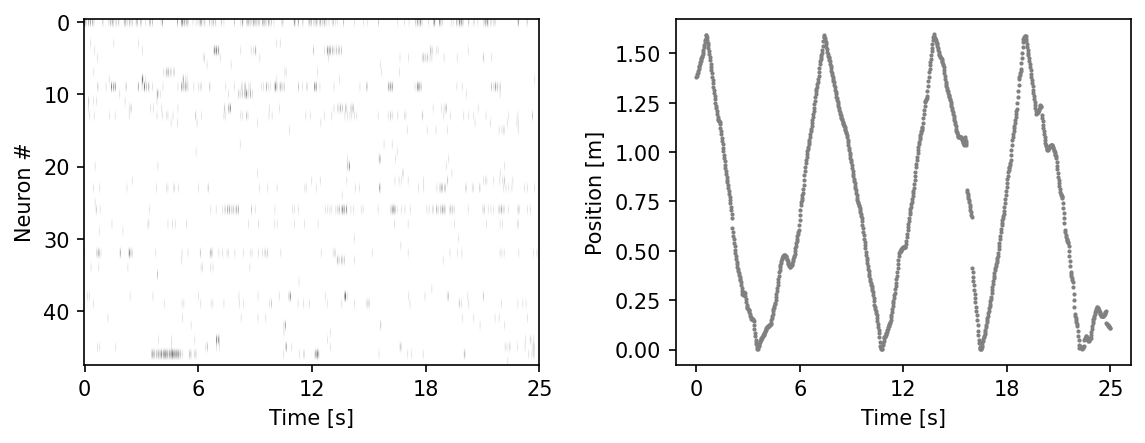

In [ ]:
fig = plt.figure(figsize=(9,3), dpi=150)
plt.subplots_adjust(wspace = 0.3)
ax = plt.subplot(121)
ax.imshow(hippocampus_pos["buddy"].neural.numpy()[:1000].T, aspect = 'auto', cmap = 'gray_r') # plots neural activity
plt.ylabel('Neuron #')
plt.xlabel('Time [s]')
plt.xticks(np.linspace(0, 1000, 5), np.linspace(0, 0.025*1000, 5, dtype = int))

ax2 = plt.subplot(122)
ax2.scatter(np.arange(1000), hippocampus_pos["buddy"].continuous_index[:1000,0], c = 'gray', s=1) # plots position vs time
plt.ylabel('Position [m]')
plt.xlabel('Time [s]')
plt.xticks(np.linspace(0, 1000, 5), np.linspace(0, 0.025*1000, 5, dtype = int))
plt.show()

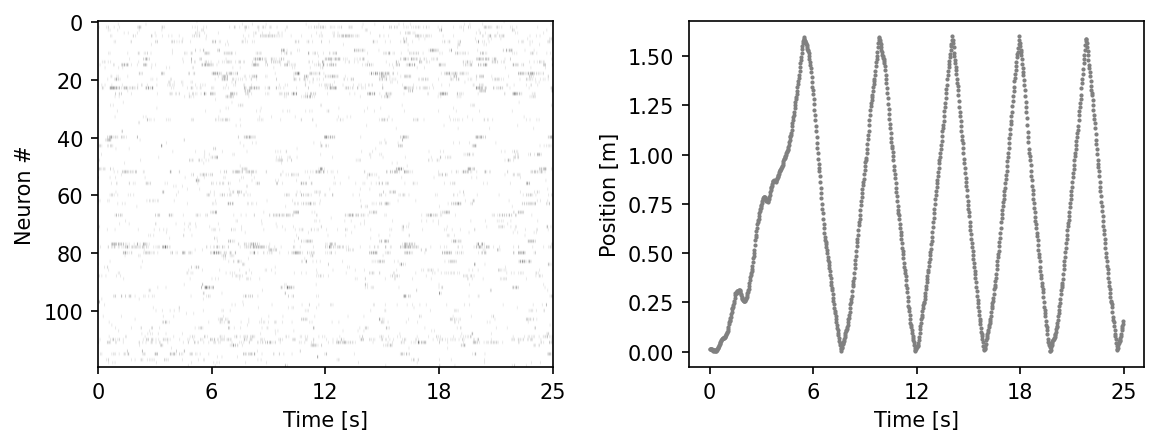

In [19]:
fig = plt.figure(figsize=(9,3), dpi=150)
plt.subplots_adjust(wspace = 0.3)
ax = plt.subplot(121)
ax.imshow(hippocampus_pos["achilles"].neural.numpy()[:1000].T, aspect = 'auto', cmap = 'gray_r')
plt.ylabel('Neuron #')
plt.xlabel('Time [s]')
plt.xticks(np.linspace(0, 1000, 5), np.linspace(0, 0.025*1000, 5, dtype = int))

ax2 = plt.subplot(122)
ax2.scatter(np.arange(1000), hippocampus_pos["achilles"].continuous_index[:1000,0], c = 'gray', s=1)
plt.ylabel('Position [m]')
plt.xlabel('Time [s]')
plt.xticks(np.linspace(0, 1000, 5), np.linspace(0, 0.025*1000, 5, dtype = int))
plt.show()

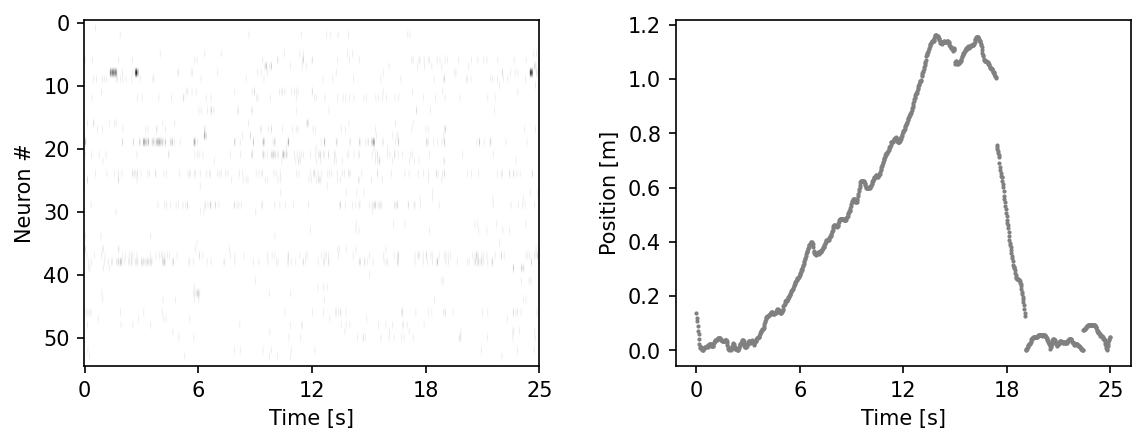

In [20]:
fig = plt.figure(figsize=(9,3), dpi=150)
plt.subplots_adjust(wspace = 0.3)
ax = plt.subplot(121)
ax.imshow(hippocampus_pos["cicero"].neural.numpy()[:1000].T, aspect = 'auto', cmap = 'gray_r')
plt.ylabel('Neuron #')
plt.xlabel('Time [s]')
plt.xticks(np.linspace(0, 1000, 5), np.linspace(0, 0.025*1000, 5, dtype = int))

ax2 = plt.subplot(122)
ax2.scatter(np.arange(1000), hippocampus_pos["cicero"].continuous_index[:1000,0], c = 'gray', s=1)
plt.ylabel('Position [m]')
plt.xlabel('Time [s]')
plt.xticks(np.linspace(0, 1000, 5), np.linspace(0, 0.025*1000, 5, dtype = int))
plt.show()

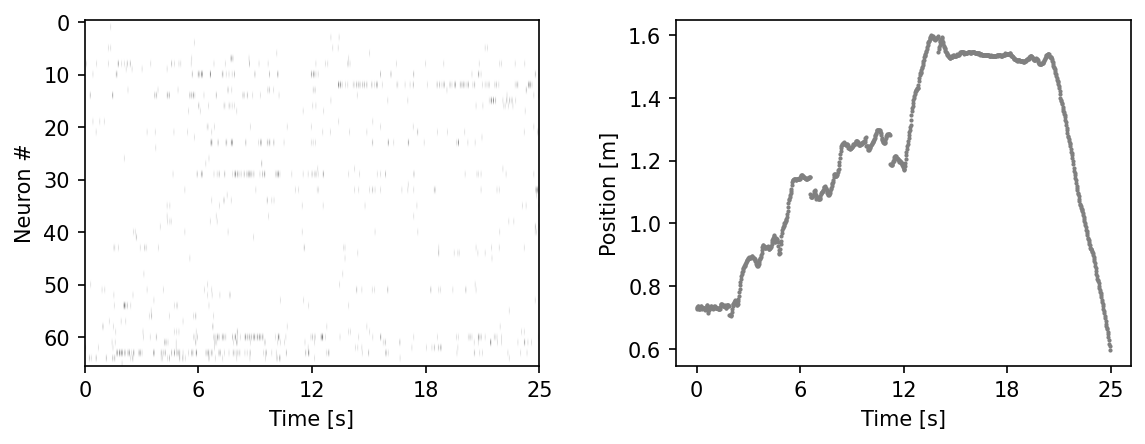

In [21]:
fig = plt.figure(figsize=(9,3), dpi=150)
plt.subplots_adjust(wspace = 0.3)
ax = plt.subplot(121)
ax.imshow(hippocampus_pos["gatsby"].neural.numpy()[:1000].T, aspect = 'auto', cmap = 'gray_r')
plt.ylabel('Neuron #')
plt.xlabel('Time [s]')
plt.xticks(np.linspace(0, 1000, 5), np.linspace(0, 0.025*1000, 5, dtype = int))

ax2 = plt.subplot(122)
ax2.scatter(np.arange(1000), hippocampus_pos["gatsby"].continuous_index[:1000,0], c = 'gray', s=1)
plt.ylabel('Position [m]')
plt.xlabel('Time [s]')
plt.xticks(np.linspace(0, 1000, 5), np.linspace(0, 0.025*1000, 5, dtype = int))
plt.show()

Train the models

In [22]:
max_iterations = 500 # quick CPU run-time demo

CEBRA-Time: Train a model with neural data only (without behavior information)

In [ ]:
time_models, time_labels = [], []

for rat in list(hippocampus_pos.keys()):

    cebra_time3_model = CEBRA(model_architecture='offset10-model', # an encoder with temporal context
                            batch_size=512,
                            learning_rate=3e-4,
                            temperature=1.12,
                            output_dimension=3, # learns 3D embedding
                            max_iterations=max_iterations,
                            distance='cosine',
                            conditional='time', # conditional distribution to use to sample the positive samples
                                                # Positive samples are distributed around the reference samples 
                                                # using the reference samples time steps
                            device='cuda_if_available',
                            verbose=True,
                            time_offsets=10)

    cebra_time3_model.fit(hippocampus_pos[rat].neural)
    time_models.append(cebra_time3_model)
    time_labels.append(f"rat: {rat}")
    cebra_time3_model.save(f"cebra_time3_model_{rat}.pt")

pos: -0.7813 neg:  6.3962 total:  5.6149 temperature:  1.1200: 100%|██████████| 500/500 [00:18<00:00, 27.03it/s]
pos: -0.6358 neg:  6.4006 total:  5.7648 temperature:  1.1200: 100%|██████████| 500/500 [00:13<00:00, 36.31it/s]
pos: -0.4279 neg:  6.3982 total:  5.9704 temperature:  1.1200: 100%|██████████| 500/500 [00:13<00:00, 36.28it/s]
pos: -0.5977 neg:  6.3886 total:  5.7910 temperature:  1.1200: 100%|██████████| 500/500 [00:14<00:00, 34.15it/s]


Text(0.5, 1.0, 'Time Contrastive Learning')

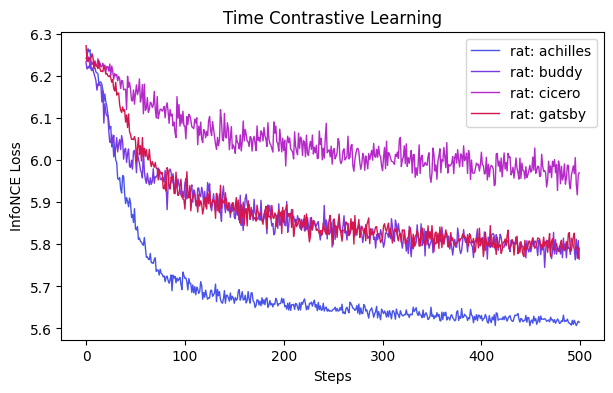

In [24]:
# plot loss curves of the models
ax = cebra.compare_models(time_models, time_labels)
ax.set_title("Time Contrastive Learning")

CEBRA-Behavior: Train a model that uses positional information (position + direction)

In [ ]:
models, labels = [], []

for rat in list(hippocampus_pos.keys()):

    cebra_posdir3_model = CEBRA(model_architecture='offset10-model',
                            batch_size=512,
                            learning_rate=3e-4,
                            temperature=1,
                            output_dimension=3,
                            max_iterations=max_iterations,
                            distance='cosine',
                            conditional='time_delta', # supervised CEBRA adding behavioral change
                            device='cuda_if_available',
                            verbose=True,
                            time_offsets=10)
    # use position labels (continuous_index) to guide the model
    cebra_posdir3_model.fit(hippocampus_pos[rat].neural, hippocampus_pos[rat].continuous_index.numpy())
    models.append(cebra_posdir3_model)
    labels.append(f"rat: {rat}")
    cebra_posdir3_model.save(f"cebra_posdir3_model_{rat}.pt")

pos: -0.8475 neg:  6.4676 total:  5.6201 temperature:  1.0000: 100%|██████████| 500/500 [00:35<00:00, 13.92it/s]
pos: -0.5961 neg:  6.4556 total:  5.8595 temperature:  1.0000: 100%|██████████| 500/500 [00:25<00:00, 19.29it/s]
pos: -0.5228 neg:  6.5486 total:  6.0258 temperature:  1.0000: 100%|██████████| 500/500 [01:24<00:00,  5.91it/s]
pos: -0.5624 neg:  6.4583 total:  5.8959 temperature:  1.0000: 100%|██████████| 500/500 [00:46<00:00, 10.82it/s]


Text(0.5, 1.0, 'Behavior(label)-guided Contrastive Learning')

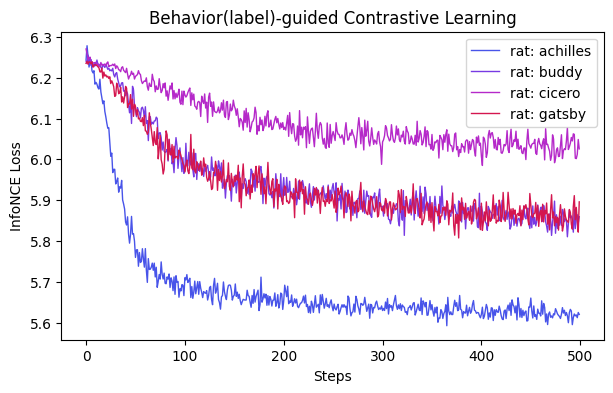

In [26]:
# plot loss curves of the models
ax = cebra.compare_models(models, labels)
ax.set_title("Behavior(label)-guided Contrastive Learning")

Load the models and get the embeddings

In [ ]:
time3_models, time3_embeddings = {}, {}
posdir3_models, posdir3_embeddings = {}, {}
left, right = {}, {}

for rat in list(hippocampus_pos.keys()):
    # time constrative models
    time3_models[rat] = cebra.CEBRA.load(f"cebra_time3_model_{rat}.pt")
    time3_embeddings[rat] = time3_models[rat].transform(hippocampus_pos[rat].neural) # projects neural data into 3D embeddings

    # behavioral contrastive models
    posdir3_models[rat] = cebra.CEBRA.load(f"cebra_posdir3_model_{rat}.pt", weights_only=False)
    posdir3_embeddings[rat] = posdir3_models[rat].transform(hippocampus_pos[rat].neural)

    # left and right labels for the embedding
    right[rat] = hippocampus_pos[rat].continuous_index[:,1] == 1 # time steps the rat was making a right turn
    left[rat] = hippocampus_pos[rat].continuous_index[:,2] == 1 # time steps the rat was making a left turn

Display the embeddings

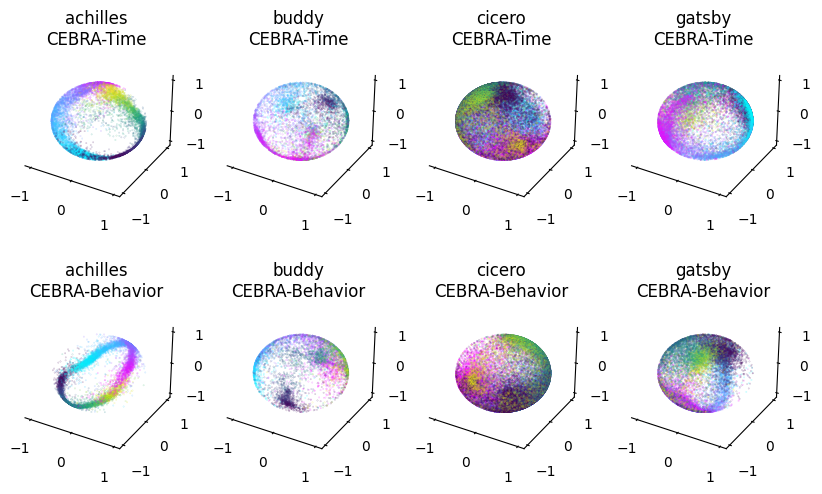

In [ ]:
%matplotlib inline

fig = plt.figure(figsize=(10,6))

ax1 = plt.subplot(241, projection='3d')
ax2 = plt.subplot(242, projection='3d')
ax3 = plt.subplot(243, projection='3d')
ax4 = plt.subplot(244, projection='3d')
axs_up = [ax1, ax2, ax3, ax4] # subplot(1–4): CEBRA-Time embeddings

ax1 = plt.subplot(245, projection='3d')
ax2 = plt.subplot(246, projection='3d')
ax3 = plt.subplot(247, projection='3d')
ax4 = plt.subplot(248, projection='3d')
axs_down = [ax1, ax2, ax3, ax4] # subplot(1–4): CEBRA-Behavior embeddings

for ax, rat in  zip(axs_up, list(time3_embeddings.keys())):
    for dir, cmap in zip([right[rat], left[rat]], ["cool", "viridis"]):
        # left/right turns used as a filter
        # then they're plotted separately, using two different colormaps: cool = right turns,  viridis = left turns
        ax=cebra.plot_embedding(ax=ax, embedding=time3_embeddings[rat][dir,:], embedding_labels=hippocampus_pos[rat].continuous_index[dir,0], title=f"{rat}\nCEBRA-Time", cmap=cmap)

for ax, rat in  zip(axs_down, list(posdir3_embeddings.keys())):
    for dir, cmap in zip([right[rat], left[rat]], ["cool", "viridis"]):
        ax=cebra.plot_embedding(ax=ax, embedding=posdir3_embeddings[rat][dir,:], embedding_labels=hippocampus_pos[rat].continuous_index[dir,0], title=f"{rat}\nCEBRA-Behavior", cmap=cmap)


plt.show()

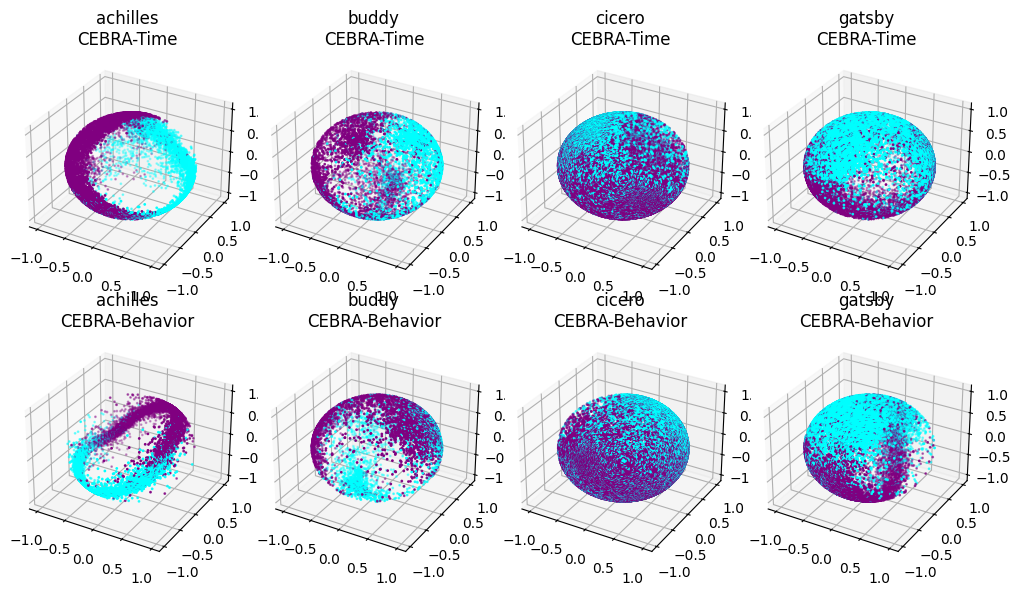

In [ ]:
''''
make left vs. right more clear
create a combined binary label array: 1 for right turns, 0 for left turns and ignore all others
Plot the embeddings using this label and a discrete colormap
aqua = left turn
purple = right turn
'''

from matplotlib.colors import ListedColormap

%matplotlib inline

fig = plt.figure(figsize=(10,6))

ax1 = plt.subplot(241, projection='3d')
ax2 = plt.subplot(242, projection='3d')
ax3 = plt.subplot(243, projection='3d')
ax4 = plt.subplot(244, projection='3d')
axs_up = [ax1, ax2, ax3, ax4]  # CEBRA-Time

ax1 = plt.subplot(245, projection='3d')
ax2 = plt.subplot(246, projection='3d')
ax3 = plt.subplot(247, projection='3d')
ax4 = plt.subplot(248, projection='3d')
axs_down = [ax1, ax2, ax3, ax4]  # CEBRA-Behavior

discrete_cmap = ListedColormap(['aqua', 'purple'])  # 0 = left, 1 = right

# CEBRA-Time Embeddings
for ax, rat in zip(axs_up, list(time3_embeddings.keys())):
    # Create binary labels: 0 for left, 1 for right, -1 for others
    labels = np.full(len(right[rat]), -1)
    labels[right[rat]] = 1
    labels[left[rat]] = 0

    # Keep only left/right turn points
    valid_idx = labels >= 0
    embedding = time3_embeddings[rat][valid_idx]
    color_labels = labels[valid_idx]

    sc = ax.scatter(embedding[:,0], embedding[:,1], embedding[:,2], c=color_labels, cmap=discrete_cmap, s=1)
    ax.set_title(f"{rat}\nCEBRA-Time")

# CEBRA-Behavior Embeddings
for ax, rat in zip(axs_down, list(posdir3_embeddings.keys())):
    labels = np.full(len(right[rat]), -1)
    labels[right[rat]] = 1
    labels[left[rat]] = 0

    valid_idx = labels >= 0
    embedding = posdir3_embeddings[rat][valid_idx]
    color_labels = labels[valid_idx]

    sc = ax.scatter(embedding[:,0], embedding[:,1], embedding[:,2], c=color_labels, cmap=discrete_cmap, s=1)
    ax.set_title(f"{rat}\nCEBRA-Behavior")

plt.tight_layout()
plt.show()



Compute the consistency maps

In [ ]:

labels = [hippocampus_pos[rat].continuous_index[:, 0]
          for rat in list(hippocampus_pos.keys())] #continuous x-position labels per rat, used to align embeddings

# CEBRA-Time consistencies
time_scores, time_pairs, time_subjects = cebra.sklearn.metrics.consistency_score(embeddings=list(time3_embeddings.values()),
                                                                                 labels=labels,
                                                                                 dataset_ids=list(
                                                                                     time3_embeddings.keys()),
                                                                                 between="datasets")

# CEBRA-Behavior consistencies
posdir_scores, posdir_pairs, posdir_subjects = cebra.sklearn.metrics.consistency_score(embeddings=list(posdir3_embeddings.values()),
                                                                                       labels=labels,
                                                                                       dataset_ids=list(
                                                                                           posdir3_embeddings.keys()),
                                                                                       between="datasets")

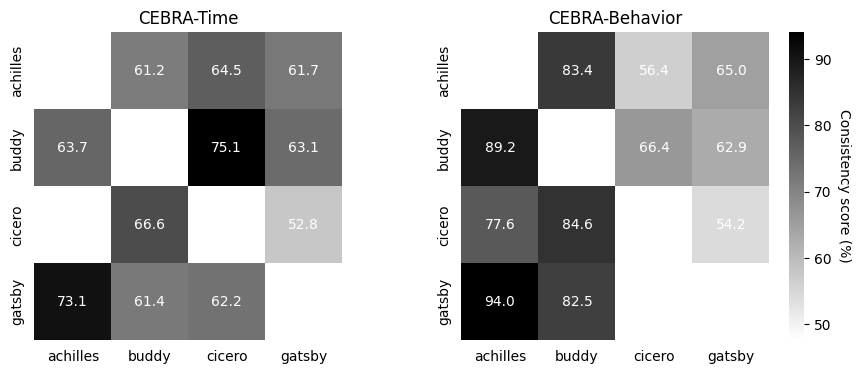

In [30]:
%matplotlib inline

# Display consistency maps
fig = plt.figure(figsize=(11, 4))

ax1 = plt.subplot(121)
ax2 = plt.subplot(122)

ax1 = cebra.plot_consistency(time_scores, pairs=time_pairs, datasets=time_subjects,
                             ax=ax1, title="CEBRA-Time", colorbar_label=None)
ax2 = cebra.plot_consistency(
    posdir_scores, pairs=posdir_pairs, datasets=posdir_subjects, ax=ax2, title="CEBRA-Behavior")